# Operational Readiness Forecast Model

This notebook ingests the Excel readiness register, reconstructs weekly readiness progress, trains a simple linear regression model, forecasts readiness percentage for future weeks, and exports the results.

This is intentionally simple and explainable because the dataset is small and the purpose is to show predictive modelling workflow rather than production grade forecasting.

In [1]:
!pip install -q pandas numpy scikit-learn matplotlib openpyxl

In [2]:
from google.colab import files
uploaded = files.upload()

# After upload, the file will be available in the current Colab working directory.
list(uploaded.keys())

Saving Operational_Readiness_PowerBI_Ready.xlsx to Operational_Readiness_PowerBI_Ready.xlsx


['Operational_Readiness_PowerBI_Ready.xlsx']

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from pathlib import Path

EXCEL_FILE = 'Operational_Readiness_PowerBI_Ready.xlsx'
SHEET_NAME = 'ReadinessRegister'
FORECAST_WEEKS = 16
TARGET_READINESS = 90

## 4. Load and prepare the readiness register

In [4]:
def convert_excel_date(series: pd.Series) -> pd.Series:
    # Converts Excel serial dates or normal date strings into pandas dates.
    numeric_version = pd.to_numeric(series, errors='coerce')

    converted_numeric = pd.to_datetime(
        numeric_version,
        unit='D',
        origin='1899-12-30',
        errors='coerce'
    )

    converted_string = pd.to_datetime(series, errors='coerce', dayfirst=True)
    return converted_string.fillna(converted_numeric)


def load_readiness_data(file_path: str) -> pd.DataFrame:
    # Loads and prepares the readiness register.
    df = pd.read_excel(file_path, sheet_name=SHEET_NAME)

    required_cols = ['PlannedCompletion', 'ActualCompletion', 'Status']
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f'Missing required columns: {missing_cols}')

    df['PlannedCompletion'] = convert_excel_date(df['PlannedCompletion'])
    df['ActualCompletion'] = convert_excel_date(df['ActualCompletion'])

    df['Status'] = df['Status'].astype(str).str.strip()
    df['IsCompleted'] = df['ActualCompletion'].notna() | df['Status'].str.lower().eq('completed')

    return df


if not Path(EXCEL_FILE).exists():
    raise FileNotFoundError(f'Could not find {EXCEL_FILE}. Please upload the Excel file in Colab first.')

df = load_readiness_data(EXCEL_FILE)
df.head()

,ItemNo,Category,Title,DocRef,PlannedCompletion,ActualCompletion,Priority,Status,Owner,IsOverdue,DaysOverdue,ScheduleVarianceDays,IsCompleted
0,1.1,Construction Phase Plan & HSW,Construction Phase Plan - is the activity conc...,NaN,2026-04-30,2026-03-30,Not Flagged,Completed,HSW Team,No,NaN,-31.0,True
1,1.2,Construction Phase Plan & HSW,Detailed activity programme issued and the who...,NaN,2026-02-16,2026-03-30,Not Flagged,Completed,Planning Team,No,NaN,42.0,True
2,1.3,Construction Phase Plan & HSW,Handover/ hand backs agreed with other contrac...,NaN,2026-05-08,2026-02-28,High,Completed,Land Access Team,No,NaN,-69.0,True
3,1.4,Construction Phase Plan & HSW,Incident Plan covers this activity & accepted?...,NaN,2026-05-29,NaT,High,Ongoing,HSW Team,Yes,22.0,NaN,False
4,1.5,Construction Phase Plan & HSW,Incident reporting process briefed.,NaN,2026-05-29,NaT,High,Ongoing,HSW Team,Yes,22.0,NaN,False


## 5. Build weekly readiness history

This converts item level completion dates into a weekly readiness percentage trend.

In [5]:
def build_weekly_readiness_history(df: pd.DataFrame) -> pd.DataFrame:
    # Creates weekly readiness history from actual completion dates.
    today = pd.Timestamp.today().normalize()

    first_date = df[['PlannedCompletion', 'ActualCompletion']].min().min()
    if pd.isna(first_date):
        first_date = today - pd.Timedelta(weeks=8)

    weekly_dates = pd.date_range(start=first_date, end=today, freq='W-MON')
    total_items = len(df)
    rows = []

    for snapshot_date in weekly_dates:
        completed_items = df[
            df['ActualCompletion'].notna() &
            (df['ActualCompletion'] <= snapshot_date)
        ].shape[0]

        readiness_pct = completed_items / total_items * 100

        rows.append({
            'SnapshotDate': snapshot_date,
            'CompletedItems': completed_items,
            'TotalItems': total_items,
            'ReadinessPct': readiness_pct
        })

    history = pd.DataFrame(rows)

    # Fallback if actual completion dates are missing but status shows completed items.
    if history.empty or history['CompletedItems'].max() == 0:
        completed_now = int(df['IsCompleted'].sum())
        history = pd.DataFrame({
            'SnapshotDate': [today - pd.Timedelta(weeks=4), today],
            'CompletedItems': [max(completed_now - 3, 0), completed_now],
            'TotalItems': [total_items, total_items],
            'ReadinessPct': [max(completed_now - 3, 0) / total_items * 100, completed_now / total_items * 100]
        })

    return history


history = build_weekly_readiness_history(df)
history.tail()

,SnapshotDate,CompletedItems,TotalItems,ReadinessPct
29,2026-05-25,20,92,21.73913
30,2026-06-01,20,92,21.73913
31,2026-06-08,20,92,21.73913
32,2026-06-15,20,92,21.73913
33,2026-06-22,20,92,21.73913


## 6. Train a simple predictive model

The model learns the relationship between week number and readiness percentage.

In [6]:
def train_forecast_model(history: pd.DataFrame):
    # Trains a simple linear regression model on readiness percentage over time.
    history = history.copy()
    history['WeekNumber'] = np.arange(len(history))

    x = history[['WeekNumber']]
    y = history['ReadinessPct']

    model = LinearRegression()
    model.fit(x, y)

    return model, history


model, history = train_forecast_model(history)
print(f'Weekly readiness growth: {model.coef_[0]:.2f} percentage points per week')

Weekly readiness growth: 0.74 percentage points per week


## 7. Forecast future readiness

In [7]:
def forecast_readiness(model, history: pd.DataFrame, weeks_ahead: int) -> pd.DataFrame:
    # Forecasts readiness percentage for the next N weeks.
    last_week_number = history['WeekNumber'].max()
    last_date = history['SnapshotDate'].max()

    future_week_numbers = np.arange(last_week_number + 1, last_week_number + weeks_ahead + 1)
    future_dates = [last_date + pd.Timedelta(weeks=i) for i in range(1, weeks_ahead + 1)]

    forecast_pct = model.predict(future_week_numbers.reshape(-1, 1))
    forecast_pct = np.clip(forecast_pct, 0, 100)

    forecast = pd.DataFrame({
        'SnapshotDate': future_dates,
        'WeekNumber': future_week_numbers,
        'ForecastReadinessPct': forecast_pct
    })

    return forecast


def find_target_date(forecast: pd.DataFrame, target_pct: float):
    # Finds the first forecast date where readiness reaches the target percentage.
    target_rows = forecast[forecast['ForecastReadinessPct'] >= target_pct]
    if target_rows.empty:
        return None
    return target_rows.iloc[0]['SnapshotDate']


forecast = forecast_readiness(model, history, FORECAST_WEEKS)
forecast['ForecastReadinessPct'] = forecast['ForecastReadinessPct'].round(2)
forecast

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


,SnapshotDate,WeekNumber,ForecastReadinessPct
0,2026-06-29,34,20.84
1,2026-07-06,35,21.57
2,2026-07-13,36,22.31
3,2026-07-20,37,23.05
4,2026-07-27,38,23.78
5,2026-08-03,39,24.52
6,2026-08-10,40,25.25
7,2026-08-17,41,25.99
8,2026-08-24,42,26.73
9,2026-08-31,43,27.46


## 8. Print executive summary

In [8]:
current_completed = int(df['IsCompleted'].sum())
total_items = len(df)
current_readiness = current_completed / total_items * 100
open_items = total_items - current_completed
weekly_growth = model.coef_[0]
target_date = find_target_date(forecast, TARGET_READINESS)

print('Operational Readiness Forecast Summary')
print('=====================================')
print(f'Total items: {total_items}')
print(f'Completed items: {current_completed}')
print(f'Open items: {open_items}')
print(f'Current readiness: {current_readiness:.2f}%')
print(f'Predicted weekly readiness growth: {weekly_growth:.2f} percentage points per week')

if target_date is not None:
    print(f'Estimated date to reach {TARGET_READINESS}% readiness: {target_date.date()}')
else:
    print(f'{TARGET_READINESS}% readiness is not reached within the next {FORECAST_WEEKS} weeks.')

Operational Readiness Forecast Summary
Total items: 92
Completed items: 21
Open items: 71
Current readiness: 22.83%
Predicted weekly readiness growth: 0.74 percentage points per week
90% readiness is not reached within the next 16 weeks.


## 9. Plot actual versus forecast readiness

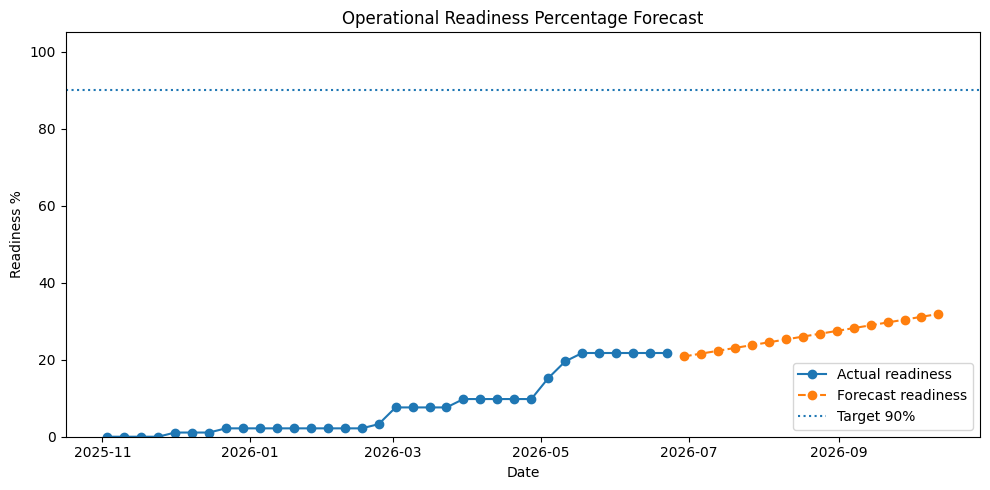

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(history['SnapshotDate'], history['ReadinessPct'], marker='o', label='Actual readiness')
plt.plot(forecast['SnapshotDate'], forecast['ForecastReadinessPct'], marker='o', linestyle='--', label='Forecast readiness')
plt.axhline(TARGET_READINESS, linestyle=':', label=f'Target {TARGET_READINESS}%')
plt.title('Operational Readiness Percentage Forecast')
plt.xlabel('Date')
plt.ylabel('Readiness %')
plt.ylim(0, 105)
plt.legend()
plt.tight_layout()
plt.show()

About this model

This model reconstructs weekly readiness progress from actual completion dates. It then uses a simple linear regression model to learn the average weekly movement in readiness percentage and projects the trend forward. I used this approach because the dataset is small, so a complex time series model would not be reliable or easy to explain.